In [2]:
# Imports
import eurostat
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Static mapping for common Eurostat geo codes
# Countries filtered out : ME, LI, UK, IS, MT, CY for low data coverage or geographic difference 
geo_map = {
    "AT": "Austria",
    "BE": "Belgium",
    "BG": "Bulgaria",
    "HR": "Croatia",
    "CZ": "Czechia",
    "DK": "Denmark",
    "EE": "Estonia",
    "FI": "Finland",
    "FR": "France",
    "DE": "Germany",
    "EL": "Greece",
    "GR": "Greece",
    "HU": "Hungary",
    "IE": "Ireland",
    "IT": "Italy",
    "LV": "Latvia",
    "LT": "Lithuania",
    "LU": "Luxembourg",
    "NL": "Netherlands",
    "PL": "Poland",
    "PT": "Portugal",
    "RO": "Romania",
    "SK": "Slovakia",
    "SI": "Slovenia",
    "ES": "Spain",
    "SE": "Sweden",
    "NO": "Norway",
    "CH": "Switzerland",
}

In [ ]:
# Asylum applications: download and reshape
ds_asyl_code = 'migr_asyappctza'

df_asyl_raw = eurostat.get_data_df(ds_asyl_code)

# Filter to total age/sex, per-100k unit, total citizenship, first-time applicants
df_asyl_filtered = df_asyl_raw[
    (df_asyl_raw['age'] == 'TOTAL') &
    (df_asyl_raw['sex'] == 'T') &
    (df_asyl_raw['unit'] == 'PER') &
    (df_asyl_raw['citizen'] == 'TOTAL') &
    (df_asyl_raw['applicant'] == 'FRST')
]

# Rename geo column and keep only countries in geo_map
df_asyl_filtered = df_asyl_filtered.rename(columns={'geo\\TIME_PERIOD': 'geo'})
df_asyl_filtered = df_asyl_filtered[df_asyl_filtered['geo'].isin(geo_map.keys())].copy()

# Keep only years 2013–2022
years = [str(y) for y in range(2013, 2023)]
cols = ['geo'] + years
df_asyl_final = df_asyl_filtered[cols].copy()

# Wide to long format
df_asyl_long = df_asyl_final.melt(
    id_vars='geo',
    value_vars=years,
    var_name='year',
    value_name='asylum_applicants',
)
df_asyl_long['year'] = df_asyl_long['year'].astype(int)
df_asyl_long = df_asyl_long.sort_values(['geo', 'year'])

# Backward fill within each country over years
df_asyl_long['asylum_applicants'] = (
    df_asyl_long.groupby('geo')['asylum_applicants'].bfill()
)

display(df_asyl_long)

,geo,year,asylum_applicants
0,AT,2013,25700.0
27,AT,2014,25700.0
54,AT,2015,85520.0
81,AT,2016,39905.0
108,AT,2017,22470.0
...,...,...,...
161,SK,2018,155.0
188,SK,2019,215.0
215,SK,2020,265.0
242,SK,2021,330.0


In [5]:
pop_code = 'demo_pjan'
df_pop_raw = eurostat.get_data_df(pop_code)

df_pop = df_pop_raw[
    (df_pop_raw['age'] == 'TOTAL') &
    (df_pop_raw['sex'] == 'T') &
    (df_pop_raw['unit'] == 'NR')
]

df_pop = df_pop.rename(columns={'geo\\TIME_PERIOD': 'geo'})

# Keep only countries present in geo_map (drop aggregates/others)
df_pop = df_pop[df_pop['geo'].isin(geo_map.keys())].copy()

years = [str(y) for y in range(2013, 2023)]
cols = ['geo'] + years
df_pop = df_pop[cols].copy()

df_pop_long = df_pop.melt(
    id_vars='geo',
    value_vars=years,
    var_name='year',
    value_name='population'
)
df_pop_long['year'] = df_pop_long['year'].astype(int)

In [6]:
display(df_pop_long)

,geo,year,population
0,AT,2013,8451860.0
1,BE,2013,11137974.0
2,BG,2013,7202556.0
3,CH,2013,8039060.0
4,CZ,2013,10516125.0
...,...,...,...
265,PT,2022,10421117.0
266,RO,2022,19042455.0
267,SE,2022,10452326.0
268,SI,2022,2107180.0


In [7]:
df_merged = df_asyl_long.merge(df_pop_long, on=['geo', 'year'], how='inner')
df_merged['asylum_per_100k'] = df_merged['asylum_applicants'] / df_merged['population'] * 100_000

In [8]:
# Use the shared geo_map to add human-readable country names
df_merged['country'] = df_merged['geo'].map(geo_map).fillna(df_merged['geo'])
display(df_merged)

,geo,year,asylum_applicants,population,asylum_per_100k,country
0,AT,2013,25700.0,8451860.0,304.075079,Austria
1,AT,2014,25700.0,8507786.0,302.076239,Austria
2,AT,2015,85520.0,8584926.0,996.164673,Austria
3,AT,2016,39905.0,8700471.0,458.653330,Austria
4,AT,2017,22470.0,8772865.0,256.130694,Austria
...,...,...,...,...,...,...
265,SK,2018,155.0,5443120.0,2.847632,Slovakia
266,SK,2019,215.0,5450421.0,3.944649,Slovakia
267,SK,2020,265.0,5457873.0,4.855371,Slovakia
268,SK,2021,330.0,5459781.0,6.044198,Slovakia


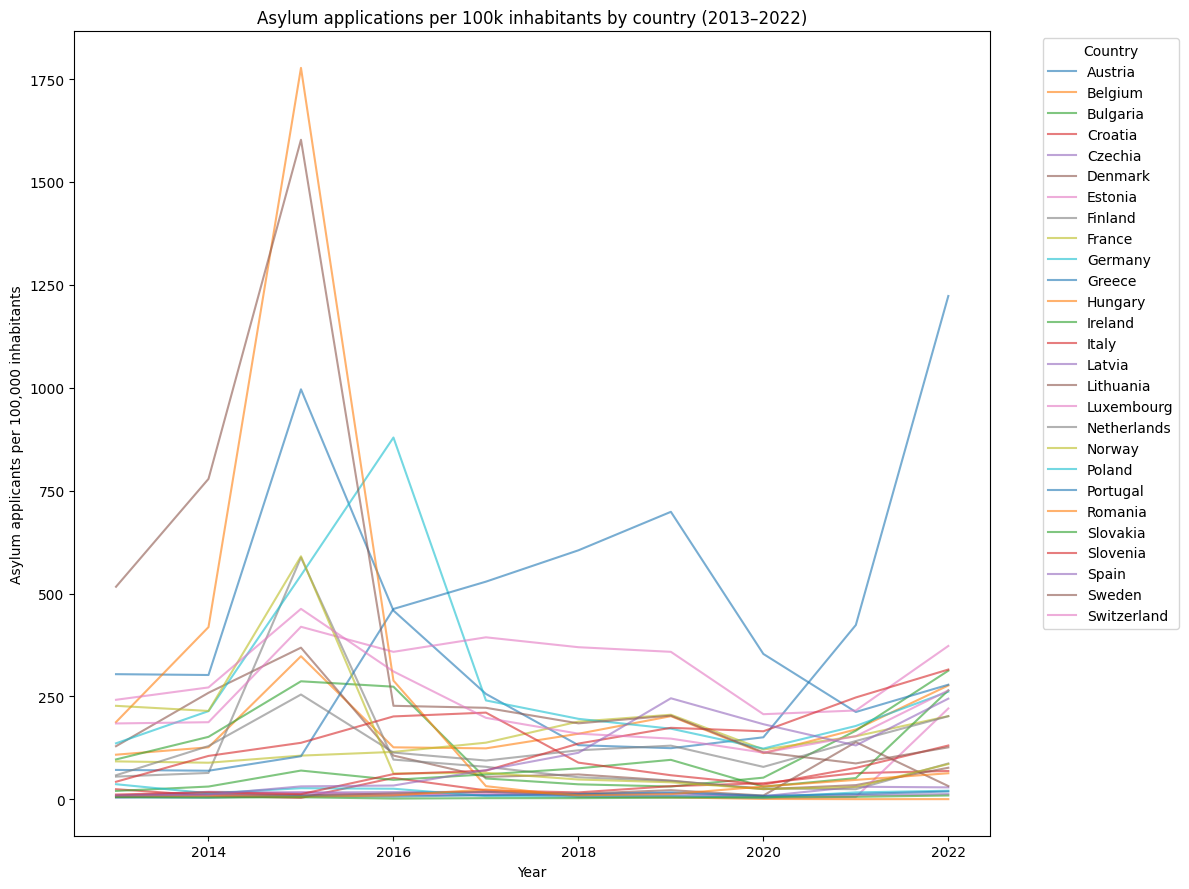

In [9]:
# Line plot of asylum applications per 100k by country over time
plt.figure(figsize=(12, 9))
for country, group in df_merged.groupby('country'):
    plt.plot(group['year'], group['asylum_per_100k'], label=country, alpha=0.6)

plt.xlabel('Year')
plt.ylabel('Asylum applicants per 100,000 inhabitants')
plt.title('Asylum applications per 100k inhabitants by country (2013–2022)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
# Download and prepare Eurostat crime data (crim_off_cat)
ds_crime_code = 'crim_off_cat'
df_crime_raw = eurostat.get_data_df(ds_crime_code)

# ICCS codes considered as (broadly) violent/serious crime
crime_codes = {
    'ICCS0101': 'Intentional homicide',
    'ICCS0301': 'Sexual violence',
    'ICCS03011': 'Rape',
    'ICCS0401': 'Robbery',
    'ICCS0502': 'Theft (and subcategories)',
}

# Filter by unit (per 100k inhabitants) and selected ICCS categories
df_crime_filtered = df_crime_raw[
    (df_crime_raw['unit'] == 'P_HTHAB') &
    (df_crime_raw['iccs'].isin(crime_codes.keys()))
]

# Rename geo column
df_crime_filtered = df_crime_filtered.rename(columns={'geo\\TIME_PERIOD': 'geo'})

# Keep only countries present in geo_map (drop aggregates/others)
df_crime_filtered = df_crime_filtered[df_crime_filtered['geo'].isin(geo_map.keys())].copy()

# Keep only years 2013–2022
years = [str(y) for y in range(2013, 2023)]
cols = ['geo', 'iccs'] + years
df_crime_wide = df_crime_filtered[cols].copy()

# Wide → long (one row per geo-year-ICCS)
df_crime_long = df_crime_wide.melt(
    id_vars=['geo', 'iccs'],
    value_vars=years,
    var_name='year',
    value_name='crime_rate_per_100k',
)
df_crime_long['year'] = df_crime_long['year'].astype(int)

# Pivot so each ICCS has its own column, preserving NaNs
df_crime_pivot = df_crime_long.pivot(
    index=['geo', 'year'],
    columns='iccs',
    values='crime_rate_per_100k',
)
df_crime_pivot.columns.name = None  # drop the column index name

# Total crime per 100k as sum of selected ICCS columns
df_crime_pivot['crime_per_100k'] = df_crime_pivot.sum(axis=1, min_count=1)
df_crime_agg = df_crime_pivot.reset_index()

In [11]:
# Final dataframe: merge asylum + population + violent crime data
df_final = df_merged.merge(df_crime_agg, on=['geo', 'year'], how='inner')
df_final.to_pickle("dataframes/df_processed.pkl")
display(df_final)

,geo,year,asylum_applicants,population,asylum_per_100k,country,ICCS0101,ICCS0301,ICCS03011,ICCS0401,ICCS0502,crime_per_100k
0,AT,2013,25700.0,8451860.0,304.075079,Austria,0.75,44.72,15.32,44.22,1822.11,1927.12
1,AT,2014,25700.0,8507786.0,302.076239,Austria,0.51,41.90,13.68,40.92,1742.86,1839.87
2,AT,2015,85520.0,8584926.0,996.164673,Austria,0.49,40.57,13.18,39.79,1635.37,1729.40
3,AT,2016,39905.0,8700471.0,458.653330,Austria,0.56,50.53,14.17,35.66,1651.67,1752.59
4,AT,2017,22470.0,8772865.0,256.130694,Austria,0.70,48.48,17.01,29.75,1501.41,1597.35
...,...,...,...,...,...,...,...,...,...,...,...,...
265,SK,2018,155.0,5443120.0,2.847632,Slovakia,1.23,12.25,1.82,8.73,316.58,340.61
266,SK,2019,215.0,5450421.0,3.944649,Slovakia,1.39,12.81,1.78,7.52,271.47,294.97
267,SK,2020,265.0,5457873.0,4.855371,Slovakia,1.15,11.34,1.69,5.95,256.57,276.70
268,SK,2021,330.0,5459781.0,6.044198,Slovakia,1.01,10.82,1.69,5.29,179.48,198.29


In [12]:
# Check missing values (NaNs) in asylum and crime data
asyl_total_count = df_asyl_long['asylum_applicants'].size
asyl_nan_count = df_asyl_long['asylum_applicants'].isna().sum()
print(f"Asylum applicants - total cells: {asyl_total_count}")
print(f"Asylum applicants - NaN count: {asyl_nan_count}\n")

crime_stats_per_code = (
    df_crime_long.groupby('iccs')['crime_rate_per_100k']
    .agg(total_count='size', nan_count=lambda s: s.isna().sum())
    .reset_index()
)

print("NaN and total counts in crime_rate_per_100k per ICCS code:")
display(crime_stats_per_code)

Asylum applicants - total cells: 270
Asylum applicants - NaN count: 0

NaN and total counts in crime_rate_per_100k per ICCS code:


,iccs,total_count,nan_count
0,ICCS0101,270,0
1,ICCS0301,270,0
2,ICCS03011,260,0
3,ICCS0401,270,0
4,ICCS0502,270,0


In [ ]:
# Check missing values coverage
cols_core = ['geo', 'country', 'year', 'asylum_per_100k', 'crime_per_100k']
df_core = df_final[cols_core].copy()
coverage = (
    df_core
    .groupby('country')[['asylum_per_100k', 'crime_per_100k']]
    .apply(lambda g: (~g.isna()).mean())   # fraction of non‑missing
    .reset_index()
)
display(coverage)

,country,asylum_per_100k,crime_per_100k
0,Austria,1.0,1.0
1,Belgium,1.0,1.0
2,Bulgaria,1.0,1.0
3,Croatia,1.0,1.0
4,Czechia,1.0,1.0
5,Denmark,1.0,1.0
6,Estonia,1.0,1.0
7,Finland,1.0,1.0
8,France,1.0,1.0
9,Germany,1.0,1.0
